In [1]:
import sys
sys.path.append('sd/')

from sd import model_loader
from sd import pipeline


from transformers import CLIPTokenizer
from PIL import Image

/Users/seyolax/projects/diffusion_acceleration/diffusion-from-scratch/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DEVICE = "mps"

tokenizer = CLIPTokenizer(vocab_file="./data/vocab.json", merges_file="./data/merges.txt")

In [3]:
model_file = "data/v1-5-pruned-emaonly.ckpt"
models = model_loader.preload_models_from_standart_weights(model_file, DEVICE)

/Users/seyolax/projects/diffusion_acceleration/diffusion-from-scratch/lib/python3.11/site-packages/lightning_fabric/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


In [4]:
def model_size_mb(model):
    total = 0
    for p in model.parameters():
        total += p.numel() * p.element_size()
    for b in model.buffers():
        total += b.numel() * b.element_size()
    return total / 1024**2


print(model_size_mb(models["diffusion"]), "MB")

3278.812271118164 MB


In [22]:
# text-to-image
prompt = "A dog on the grass with sunglasses, highly detailed, ultra sharp, cinematic, 8k resolution"
uncond_prompt = ""
do_cfg = True
cfg_scale = 7.5

## image-to-image
input_image = None
image_path = "./images/dog_example.jpeg"
input_image = Image.open(image_path)
strength = 0.75

sampler = "ddpm"
num_inference_step = 50
seed = 23

In [23]:
out_image = pipeline.generate(
    prompt=prompt,
    uncond_prompt=uncond_prompt,
    input_image=input_image,
    strength=strength,
    do_cfg=do_cfg,
    cfg_scale=cfg_scale,
    sampler_name=sampler,
    n_inference_steps=num_inference_step,
    model=models,
    seed=seed,
    tokenizer=tokenizer,
    device="cpu"
)

100%|██████████| 37/37 [02:53<00:00,  4.68s/it]


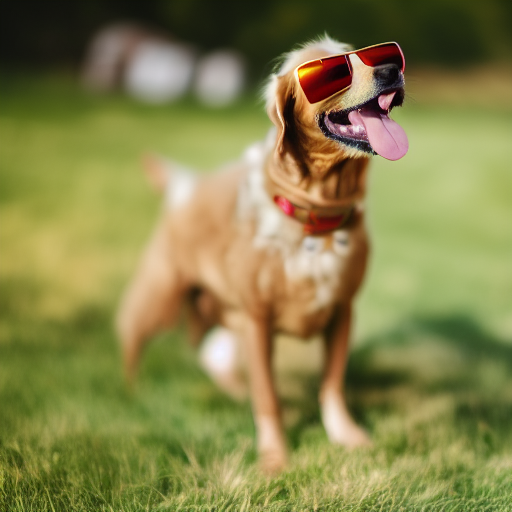

In [24]:
img = Image.fromarray(out_image)
img 